# Experiment 2: Prompt structure changes (v0 – v5)

Model, texts (working100), reps and the base prompt (the exp-1 winner: B) are frozen. Only the prompt *structure* varies, cumulatively.

| rung | change | intended to affect | how it is judged |
|---|---|---|---|
| v0 | baseline (exp-1 winner) | --- | reference point |
| v1 | reason before code | calibration | confidence / consistency; codes should not move much |
| v2 | + taxon (GBIF species, family) | thin-text rows | should help disproportionately where the text is sparse |
| v3 | + structured labelled fields | --- | no specific expectation |
| v4 | + species guardrail & cultivation flag | cultivated rows | qualitative, on a handful of rows |
| v5 | + top-3 | ambiguity detection | whether the extra matches carry usable signal |

Each rung is judged against the rung below it, on the axis it was meant to affect. There is no single score that ranks all six.

### Interpreting agreement

Agreement with the CLC reference is reported throughout, but it should be read with care. If `unambiguous` rows agree less than `thin` rows, that points at the reference rather than the model: the 25 ha minimum mapping unit cannot resolve the detailed location described in the text,
whereas a thin row pushes the model toward guessing the regional dominant cover (which is what CLC measures).

In [ ]:
import sys
import os
import pandas as pd
sys.path.insert(0, os.path.abspath('../..'))

from util.config import DEFAULT_MODEL, RESULT_PATH, WORKING_DATA100
from testing.util.gee_mapping import get_clc_mapping

from testing.util.analysis import cells_of, load_reference, guard, token_guard, topn_signals, cost_of
from testing.util.plots import plot_staircase, plot_agreement_by_difficulty_and_version, plot_topn_signals, plot_cost_by_version

MODEL, REPS, N_VERSIONS = DEFAULT_MODEL, 5, 6
REF = load_reference(f'{RESULT_PATH}/corine_output_working.csv')

EXP_PATH = f'{RESULT_PATH}/exp2'
OUTPUT = f'{EXP_PATH}/exp2_output.csv'

get_clc_mapping(WORKING_DATA100, f'{EXP_PATH}/corine_output.csv')
REF = load_reference(f'{EXP_PATH}/corine_output.csv')

# produced by:  python -m testing.util.exp2.staircase --input data/working100.csv --reps 5
raw = pd.concat([pd.read_csv(f'{EXP_PATH}/version_{i}.csv', dtype={'id': str, 'clc_code': str, 'version': int})
                 for i in range(N_VERSIONS)], ignore_index=True)
print(f'{raw.shape} | {raw['id'].nunique()} rows * {raw['rep'].nunique()} reps * {raw['version'].nunique()} versions')

(3060, 31) | 102 rows * 5 reps * 6 versions


In [6]:
for i in range(N_VERSIONS):
    guard(raw[raw.version == i], expect_variant=f'v{i}', expect_model=MODEL, label=f'v{i}')
token_guard(raw, by='version')   # prompts that differ must differ in token count

mean prompt tokens by version (must differ where prompts differ):
version
0    1832.3
1    1832.3
2    1841.3
3    1849.4
4    1936.5
5    1936.5
Name: clc_prompt_tokens, dtype: float64


version
0    1832.3
1    1832.3
2    1841.3
3    1849.4
4    1936.5
5    1936.5
Name: clc_prompt_tokens, dtype: float64

In [7]:
cells = pd.concat([cells_of(raw[raw.version == i], REF).assign(version=i)
                   for i in range(N_VERSIONS)], ignore_index=True)
LOW = {'thin', 'edge_no_signal', 'edge_cultivated'}
cells['thin'] = cells['difficulty'].isin(LOW)
print(len(cells), 'cells |', cells['ref'].notna().sum(), 'with a reference')

612 cells | 594 with a reference


### The staircase

`d_*` columns give the marginal effect of each rung relative to the rung below it.

In [8]:
summary = cells.groupby('version').agg(
    mean_conf=('mean_conf', 'mean'), consistency=('consistency', 'mean'),
    agree_L1=('agree_L1', 'mean'), agree_L3=('agree_L3', 'mean'),
    parse_fail=('parse_fail', 'mean'), unknown=('unknown_code', 'mean'),
).round(3)
for col in ['mean_conf', 'consistency', 'agree_L1', 'agree_L3']:
    summary[f'd_{col}'] = summary[col].diff().round(3)
display(summary)

,mean_conf,consistency,agree_L1,agree_L3,parse_fail,unknown,d_mean_conf,d_consistency,d_agree_L1,d_agree_L3
version,,,,,,,,,,
0,0.395,0.947,0.343434,0.080808,0.0,0.0,NaN,NaN,NaN,NaN
1,0.490,0.894,0.292929,0.040404,0.0,0.0,0.095,-0.053,-0.051,-0.04
2,0.563,0.925,0.313131,0.070707,0.0,0.0,0.073,0.031,0.02,0.03
3,0.534,0.892,0.353535,0.060606,0.0,0.0,-0.029,-0.033,0.04,-0.01
4,0.503,0.904,0.333333,0.050505,0.0,0.0,-0.031,0.012,-0.02,-0.01
5,0.572,0.896,0.333333,0.060606,0.0,0.0,0.069,-0.008,0.0,0.01


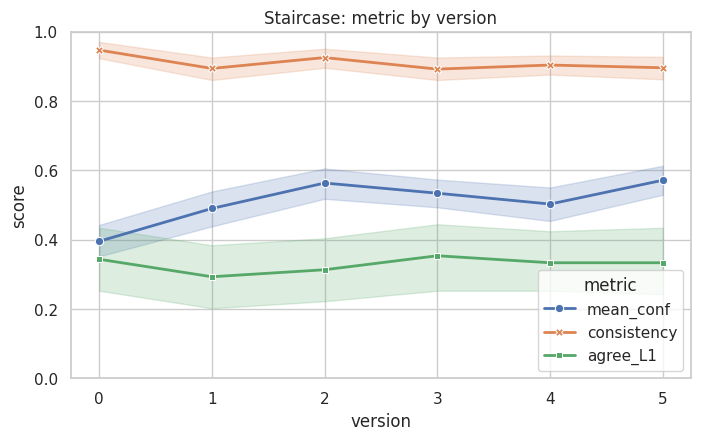

In [10]:
stairs = plot_staircase(cells, metrics=('mean_conf', 'consistency', 'agree_L1'))

Agreement and consistency stay pretty flat, whereas confidence rises. This means the model gets more certain with its predictions. Whether this is a good or bad thing cannot be judged without proper examination. \
It could be bad if agreement was something that measured accuracy, but it doesn't. High agreement can even become bad, as, due to the resolution of the official mapping, it implies the model makes decisions based on broad regions instead of classifying detailed environments.

### Agreement by difficulty

The comparison of interest is `unambiguous` against `thin`. If the former is lower, the
reference is the more likely explanation than the model.

In [11]:
piv = cells[cells.version.isin([1, 2])].pivot_table(
    index='difficulty', columns='version', values='agree_L1', aggfunc='mean').round(3)
display(piv)

version,1,2
difficulty,,
boundary_candidate,0.388889,0.388889
thin,0.341463,0.341463
unambiguous_candidate,0.2,0.25


2026-07-12 22:40:20,805 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-12 22:40:20,814 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/util/plots.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


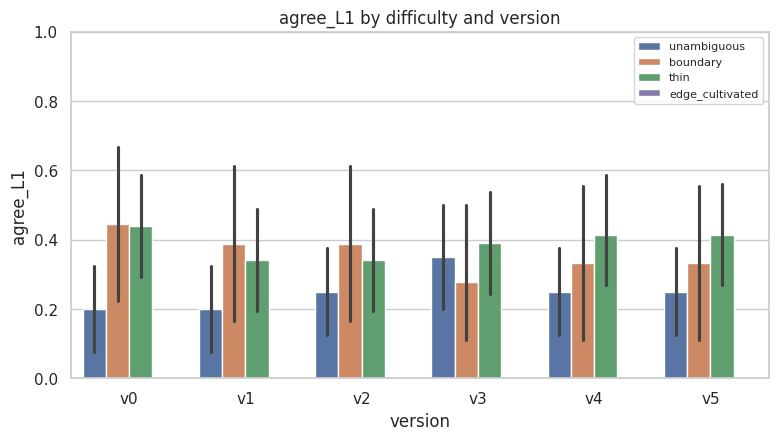

In [21]:
p = plot_agreement_by_difficulty_and_version(cells, level='agree_L1')

Version 4 and 5 show a clear staircase, where agreement and difficulty agree linearly.

### v4: the cultivation guardrail

This rung targets a small number of cultivated specimens, so no aggregate can measure it.
The outputs are read directly.

In [14]:
cult = raw[raw['difficulty'] == 'edge_cultivated']
for rid in cult['id'].unique():
    print(f'=== {rid} ===')
    for v in (3, 4):
        g = raw[(raw.id == rid) & (raw.version == v)]
        if g.empty: continue
        r = g.iloc[0]
        # check the assembled prompt, not the word: 'cultivated' also occurs in some
        # locality text, so a naive substring search gives false positives
        print(f"  v{v}: {r['clc_code']} conf={r['clc_confidence']} "
              f"| species line present: {'Species:' in str(r['clc_input'])}")
        print(f"      {str(r['clc_reason'])[:140]}")
    print()

=== W019 ===
  v3: 333 conf=0.72 | species line present: True
      High-mountain calcareous scree (Kalkschutt) and rocky fissures (Kalkfelsspalten) with small depressions; this best fits sparsely vegetated/o
  v4: 333 conf=0.62 | species line present: True
      Locality describes limestone scree (Kalkschutt), limestone rock fissures (Kalkfelsspalten) and clayey depressions above the current treeline

=== W020 ===
  v3: 332 conf=0.42 | species line present: True
      “Alte Mauern” (old stone walls) and “Silikat” indicate exposed rocky/stone substrate rather than vegetation or water; best fit is bare rock/
  v4: 332 conf=0.42 | species line present: False
      Locality mentions old stone walls ('alte Mauern') made of silicate; this indicates exposed rocky/bare substrate rather than vegetation or wa

=== W021 ===
  v3: 141 conf=0.42 | species line present: True
      A botanic garden implies managed cultivated grounds with planted vegetation; among available CLC classes, the closest p

Version 4 was able to classify one of the three cultivated plants differently. This shows an improvement.

### v5: top-3

Two candidate ambiguity signals are available from the additional matches: the confidence gap between the first and second match and the number of distinct CLC level-1 families the three matches span. Which of the two is informative is an open question. A small gap could mean the habitat is ambiguous or simply that the text carries no signal at all.

In [15]:
v5 = topn_signals(raw[raw.version == 5], REF)
print('matches returned per call:', v5['n_returned'].value_counts().to_dict())
print('\nconfidence gap by difficulty:')
display(v5.groupby('difficulty')['conf_gap'].agg(['mean', 'count']).round(3))
print('\nL1-spread by difficulty (distinct level-1 families among the top 3):')
display(v5.groupby('difficulty')['l1_spread'].agg(['mean', 'count']).round(3))
print(f"\nCalls where the reference was not the top pick but was in the top 3: "
      f"{int(v5['ref_rescued'].sum())}")

matches returned per call: {3: 510}

confidence gap by difficulty:


,mean,count
difficulty,,
boundary_candidate,0.290,90
edge_cultivated,0.134,15
thin,0.144,205
unambiguous_candidate,0.264,200



L1-spread by difficulty (distinct level-1 families among the top 3):


,mean,count
difficulty,,
boundary_candidate,1.733,90
edge_cultivated,1.400,15
thin,1.615,205
unambiguous_candidate,2.050,200



Calls where the reference was not the top pick but was in the top 3: 68


/home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/util/plots.py:259: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_short(d) for d in order], rotation=20, ha='right')
/home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/util/plots.py:259: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_short(d) for d in order], rotation=20, ha='right')


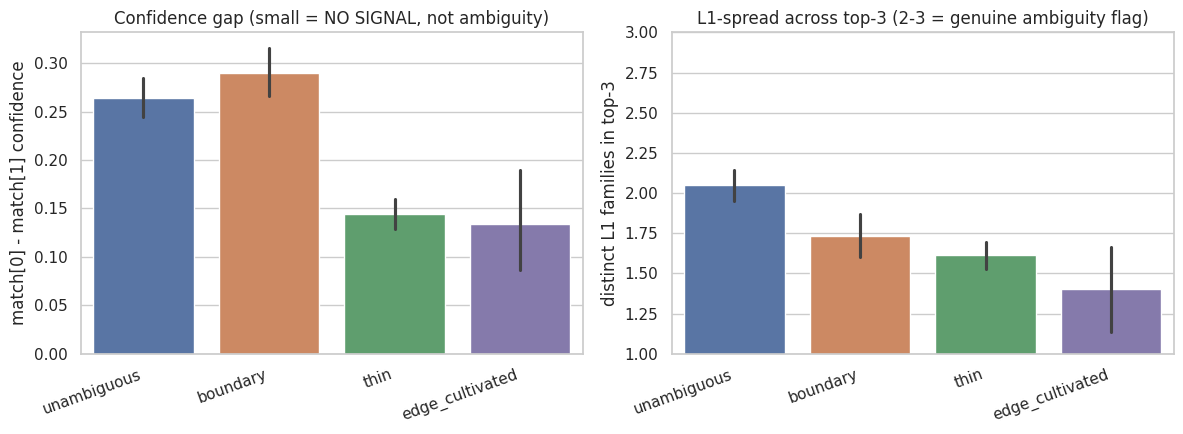

In [17]:
topn = plot_topn_signals(v5)

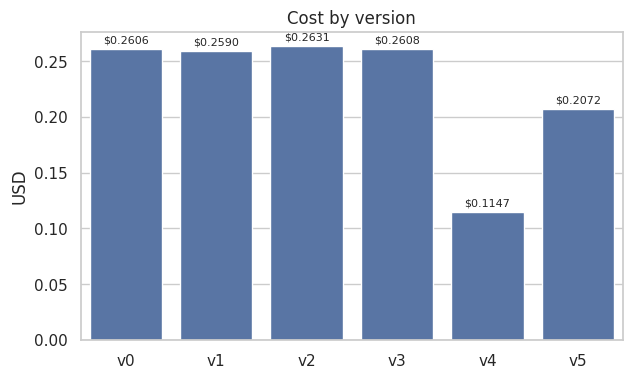

In [20]:
cost = raw.groupby('version').apply(
    lambda g: cost_of(g['clc_prompt_tokens'].sum(), g['clc_completion_tokens'].sum(),
                      g['clc_cached_tokens'].sum(), MODEL), include_groups=False)
p_cost = plot_cost_by_version(cost)

The cost drastically decreases from v3 to v4 as system prompts were partially cached.

## Conclusion

| rung | effect | evidence | 
|---|---|---|
| v1 reason-first | slight increase in confidence | conf 0.395 -> 0.490 |
| v2 taxon | slight increase in confidence | conf 0.490 -> 0.563 | 
| v3 structure | no real change |  |
| v4 guardrail | recognizes some cultivated plants |  |
| v5 top-3 | adds signals| 68 references recovered in the top 3 |

**Carried forward:** `v5`

As the other versions did not clearly harm the output all changes up to v5 are adopted.